<a href="https://colab.research.google.com/github/AlvinMathew001/AI-ML-Internship/blob/main/day4_image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

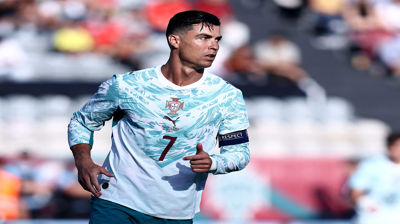

In [2]:
from PIL import Image
image=Image.open("/content/ronaldo.jpg")
image_resized=image.resize((400,224))
image
image_resized

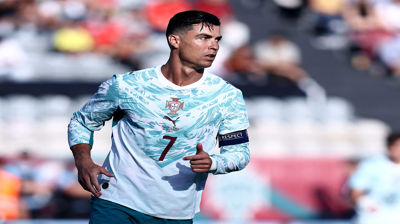

In [3]:
image_resized

In [5]:
import numpy as np
image_array=np.array(image)/255.0 # Normalize
image_array

array([[[0.6       , 0.56078431, 0.59607843],
        [0.60392157, 0.56470588, 0.6       ],
        [0.59607843, 0.55686275, 0.59215686],
        ...,
        [0.57647059, 0.41176471, 0.42745098],
        [0.56470588, 0.38823529, 0.40784314],
        [0.57254902, 0.39607843, 0.40784314]],

       [[0.55686275, 0.50980392, 0.54901961],
        [0.56078431, 0.51372549, 0.55294118],
        [0.56078431, 0.50980392, 0.54901961],
        ...,
        [0.54117647, 0.38431373, 0.38823529],
        [0.53333333, 0.36862745, 0.37647059],
        [0.5372549 , 0.37254902, 0.38039216]],

       [[0.56470588, 0.50196078, 0.54509804],
        [0.56470588, 0.50196078, 0.54509804],
        [0.55686275, 0.49411765, 0.53333333],
        ...,
        [0.54117647, 0.38823529, 0.39215686],
        [0.53333333, 0.37647059, 0.38039216],
        [0.5254902 , 0.36862745, 0.36862745]],

       ...,

       [[0.62745098, 0.68627451, 0.80784314],
        [0.63137255, 0.69019608, 0.81176471],
        [0.62352941, 0

array([[131, 127, 123, ..., 119, 114, 105],
       [108, 105,  98, ..., 125, 120, 116],
       [ 85,  82,  78, ..., 142, 138, 134],
       ...,
       [184, 185, 184, ..., 254, 254, 254],
       [185, 183, 177, ..., 254, 254, 254],
       [182, 176, 170, ..., 254, 254, 254]], dtype=uint8)
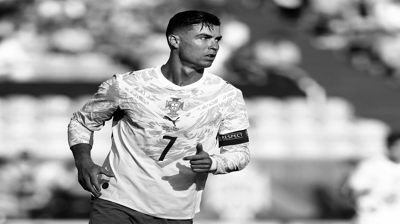

In [10]:
from cv2 import cvtColor,COLOR_BGR2GRAY
image_np=np.array(image_resized)
grayscale_image=cvtColor(image_np,COLOR_BGR2GRAY)
grayscale_image



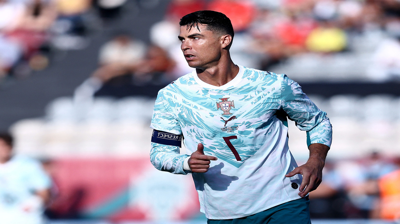

In [15]:
from PIL import Image,ImageEnhance,ImageOps
flipped=ImageOps.mirror(image_resized)
flipped

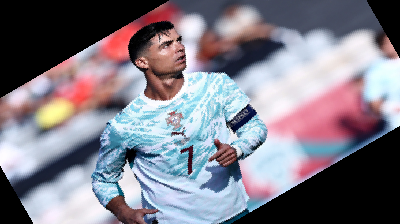

In [18]:
rotate=image_resized.rotate(30)
rotate

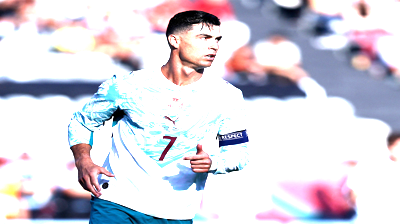

In [24]:
enhancer=ImageEnhance.Brightness(image_resized)
enhanced=enhancer.enhance(2)
enhanced

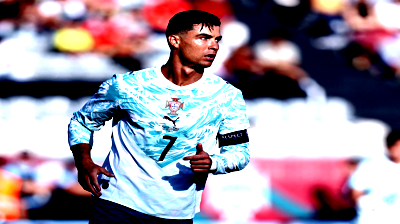

In [25]:
contrast=ImageEnhance.Contrast(image_resized)
contrasted=contrast.enhance(2)
contrasted

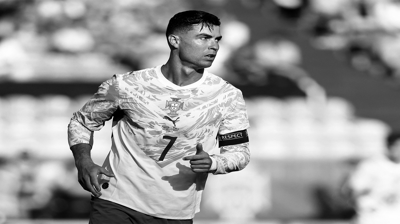

In [26]:
grayscale=ImageOps.grayscale(image_resized)
grayscale

In [28]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = "/content/ronaldo.jpg"  # Replace with your image file path
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


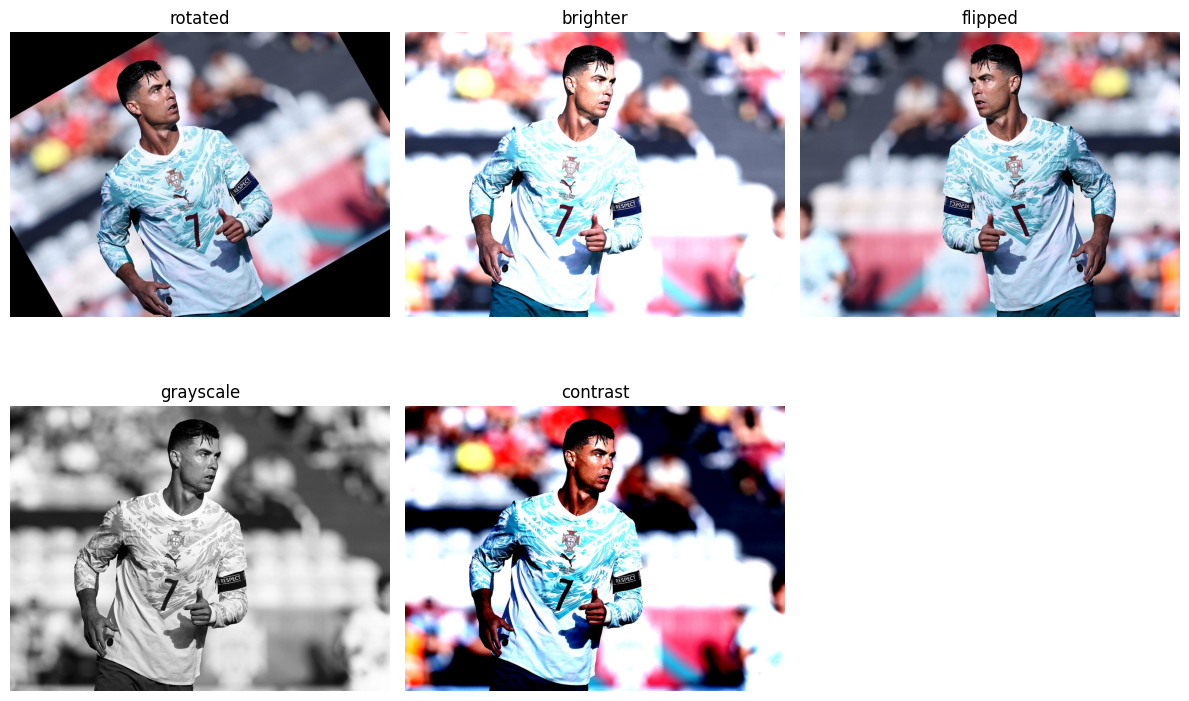

In [34]:
import matplotlib.pyplot as plt

augmented_dir="augmented_images"

augmented_images=os.listdir(augmented_dir)

plt.figure(figsize=(12,8))

for i,img_file in enumerate(augmented_images):
  img_path=os.path.join(augmented_dir,img_file)
  img=Image.open(img_path)
  plt.subplot(2,3,i+1)
  plt.imshow(img,cmap="gray" if img.mode=="L" else None)

  plt.title(img_file.split('.')[0])
  plt.axis("off")

plt.tight_layout()
plt.show()